# Telco Customer Churn Prediction

A machine learning project to predict customer churn for a telecom company using the [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

## Overview
This project explores which customer attributes (contract type, tenure, monthly charges, internet service, etc.) are associated with churn, then builds a K-Nearest Neighbors (KNN) classifier to predict whether a customer will churn.

## Dataset
- 7,043 customer records, 21 original features
- Target variable: `Churn` (Yes/No)
- Class imbalance: ~73% No churn, ~27% Yes churn

## Workflow
1. **Data Cleaning** — dropped non-predictive/redundant columns (`customerID`, `Dependents`, `TotalCharges`), checked for nulls and duplicates
2. **Exploratory Data Analysis** — visualized churn distribution, churn by contract type, tenure, monthly charges, internet service, and payment method using Seaborn/Matplotlib
3. **Preprocessing**
   - Label-encoded binary categorical columns (`gender`, `Partner`, `PhoneService`, `PaperlessBilling`, `Churn`)
   - One-hot encoded multi-category columns (`MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod`)
   - Train/test split (80/20)
4. **Handling Class Imbalance** — applied SMOTE (Synthetic Minority Over-sampling) on the training set
5. **Feature Scaling** — StandardScaler applied after resampling
6. **Modeling** — trained a K-Nearest Neighbors classifier (k=7)
7. **Evaluation** — confusion matrix, accuracy score, and classification report (precision, recall, F1)

## Tools & Libraries
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `imbalanced-learn` (SMOTE)

## Results
See the notebook's classification report and confusion matrix for detailed precision/recall/F1 metrics on the churn class.

## Future Improvements
- Compare KNN against Logistic Regression, Random Forest, and XGBoost
- Hyperparameter tuning (k value, distance metric)
- Feature importance analysis to refine column selection

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/Telco_Cusomer_Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [202]:
df=df.drop(columns=['customerID','Dependents','TotalCharges'])

In [203]:
df.shape

(7043, 18)

In [204]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object
DeviceProtection,object


In [205]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [206]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


In [207]:
df.duplicated().sum()

np.int64(36)

In [208]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'Churn'],
      dtype='object')

In [209]:
l=[ 'gender', 'SeniorCitizen', 'Partner',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'Churn']

for i in l:
  print(i)
  print(df[i].unique())
  print('*'*100)

gender
['Female' 'Male']
****************************************************************************************************
SeniorCitizen
[0 1]
****************************************************************************************************
Partner
['Yes' 'No']
****************************************************************************************************
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
****************************************************************************************************
PhoneService
['No' 'Yes']
****************************************************************************************************
MultipleLines
['No phone service' 'No' 'Yes']
****************************************************************************************************
InternetService
['DSL' 'F

In [210]:
for i in l:
  print(i)
  print(df[i].value_counts())
  print()

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
Dev

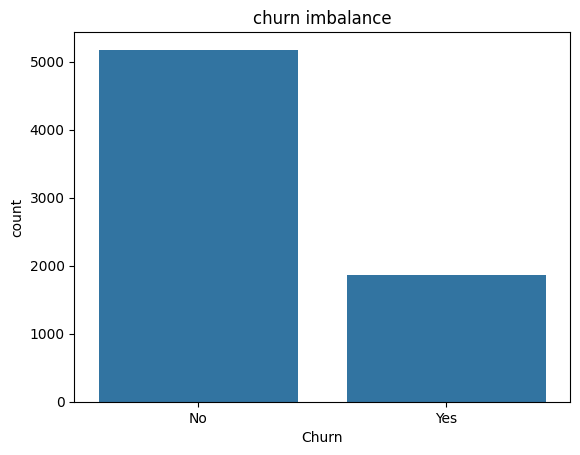

In [211]:
# are the churn data balanced

sns.countplot(x=df['Churn'],data=df)
plt.title("churn imbalance")
plt.show()

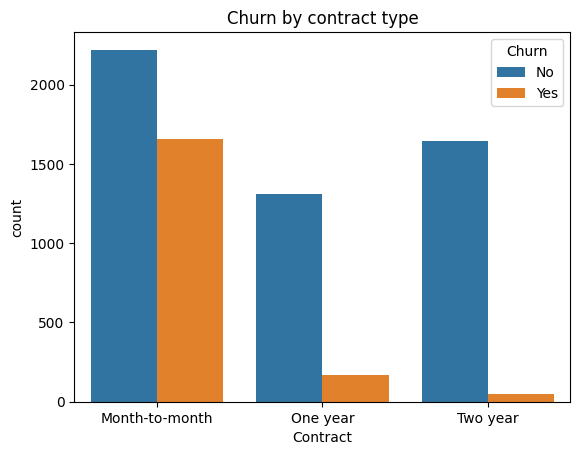

In [212]:
sns.countplot(x=df['Contract'],hue=df['Churn'],data=df)
plt.title('Churn by contract type')
plt.show()

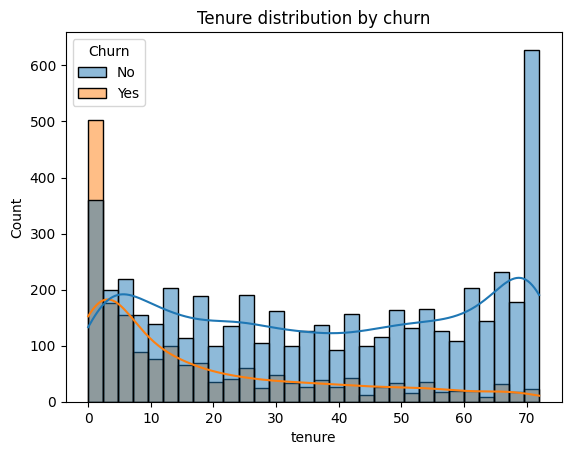

In [213]:
sns.histplot(x=df['tenure'],hue=df['Churn'],kde=True,bins=30,data=df)
plt.title('Tenure distribution by churn')
plt.show()

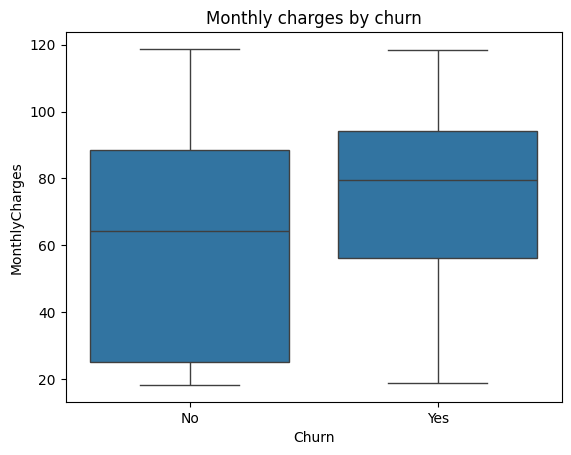

In [214]:
sns.boxplot(x=df['Churn'],y=df['MonthlyCharges'],data=df)
plt.title('Monthly charges by churn')
plt.show()

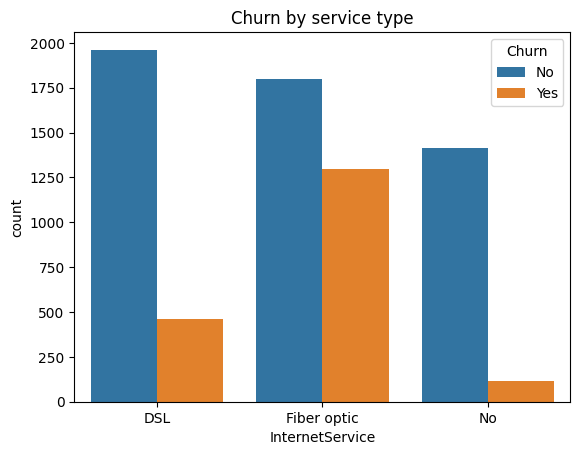

In [215]:
sns.countplot(x=df['InternetService'],hue=df['Churn'],data=df)
plt.title('Churn by service type')
plt.show()

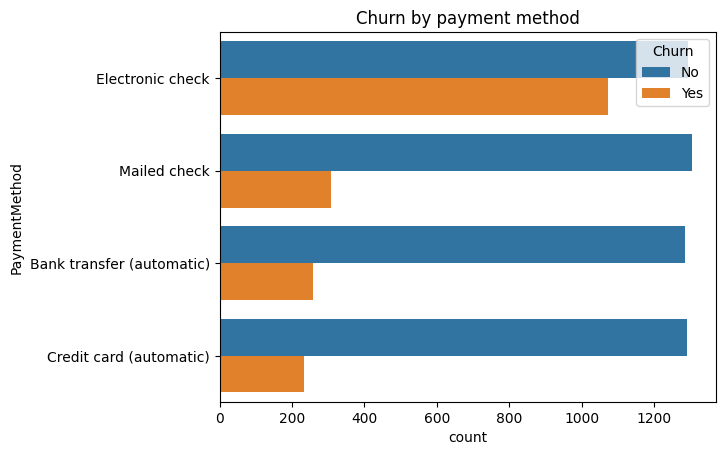

In [216]:
sns.countplot(y=df['PaymentMethod'],hue=df['Churn'],data=df)
plt.title('Churn by payment method')
plt.show()

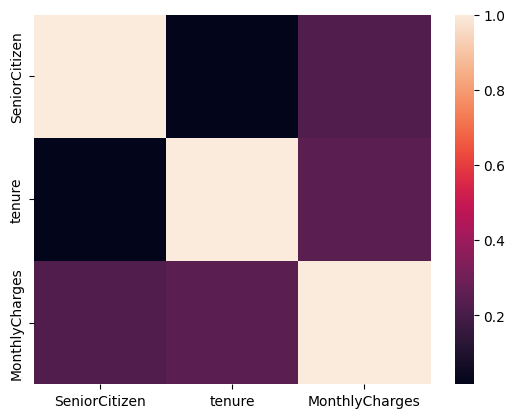

In [217]:
from numpy._core import numeric
sns.heatmap(df.corr(numeric_only=True))
plt.show()

In [218]:
df.head()

,gender,SeniorCitizen,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,Female,0,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [219]:
from sklearn.preprocessing import LabelEncoder
binary_cols = ['gender', 'Partner', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for i in binary_cols:
    df[i] = le.fit_transform(df[i])
df

,gender,SeniorCitizen,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,0
1,1,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,0
2,1,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,1
3,1,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,0
4,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,0
7039,0,0,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,0
7040,0,0,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,0
7041,1,1,1,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,1


In [220]:
df

,gender,SeniorCitizen,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,0
1,1,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,0
2,1,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,1
3,1,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,0
4,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,0
7039,0,0,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,0
7040,0,0,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,0
7041,1,1,1,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,1


In [221]:
x=df.drop(columns='Churn')

In [222]:
y=df['Churn']

In [223]:
x.ndim

2

In [224]:
y.ndim

1

In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   int64  
 15  PaymentMethod     7043 non-null   object 
 16  MonthlyCharges    7043 non-null   float64


In [226]:
# train test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [227]:
x

,gender,SeniorCitizen,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,0,0,1,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85
1,1,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95
2,1,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85
3,1,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30
4,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80
7039,0,0,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20
7040,0,0,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60
7041,1,1,1,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40


In [228]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
column_transformer = make_column_transformer(
    (OneHotEncoder(drop='first', sparse_output=False), multi_cols),
    remainder='passthrough')
x_train = column_transformer.fit_transform(x_train)   # learns categories from train
x_test = column_transformer.transform(x_test)

In [229]:
x_train.shape

(5634, 28)

In [230]:
x_test.shape

(1409, 28)

In [231]:
y_train.value_counts()

,count
Churn,
0,4138
1,1496


In [232]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

In [233]:
# scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_res=scaler.fit_transform(x_train_res)
x_test=scaler.transform(x_test)

In [234]:
# model creation

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_res,y_train_res)

KNeighborsClassifier(n_neighbors=7)

In [235]:
y_pred = knn.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [236]:
y_test.values

array([1, 0, 0, ..., 0, 0, 1])

In [237]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
cm

array([[725, 311],
       [ 84, 289]])

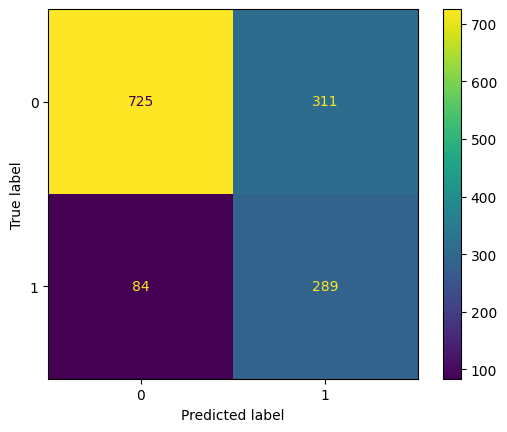

In [238]:
cmd=ConfusionMatrixDisplay(cm)
cmd.plot()

In [239]:
score=accuracy_score(y_test,y_pred)
score

0.7196593328601846

In [240]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1036
           1       0.48      0.77      0.59       373

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.74      1409

